# 03 - GQE: a GPT that writes quantum circuits

**The idea (from Nakaji et al. 2024).** In VQE you fix a circuit and tune its
angles. In GQE you fix a menu of gates and let a language model choose *which
gates, in which order*. All the trainable parameters live in the classical
model, not in the circuit.

**Our menu (the operator pool).** The paper used chemistry gates. Those mean
nothing for RNA, so we use two kinds:

- `cost(gamma)`  = `exp(-i*gamma*H)` writes the RNA energy into the phases
- `mix(beta)`    = `exp(-i*beta*sum X)` turns those phases into real
  differences in probability

**You need both.** Cost gates alone only change phases, so measuring gives a
flat, useless distribution. We check this below.

**One change we had to make.** In chemistry you minimise the average energy.
Here the Hamiltonian is diagonal, so the average is the average over *all*
structures, which is not what we want. We use **CVaR** instead: the mean
energy of the best 15% of the distribution. This looks only at the good tail.

### How to run this notebook

This notebook runs on its own. You do not need the others open.

1. Put **gqe-rna.zip** at the top level of your Google Drive (My Drive).
   Do this once. You never need to unzip it yourself.
2. In Colab: **File -> Upload notebook** and pick this file.
3. **Runtime -> Change runtime type -> T4 GPU** (free tier is fine).
4. **Runtime -> Run all**. Approve the Drive popup when it appears.

Results are saved into `gqe-rna/results/` **in your Drive**, so they survive
when the runtime shuts down and the next notebook picks them up automatically.

If a cell says a file is missing, run the notebook it names first.

In [1]:
# STEP 1 - Connect to Drive and find the project.
# Put gqe-rna.zip at the top level of My Drive. Do not unzip it yourself.
import sys, os, glob, subprocess, importlib

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive"
REPO = os.path.join(ROOT, "gqe-rna")

# Unzip once, if the folder is not there yet.
if not os.path.isdir(os.path.join(REPO, "src")):
    zp = os.path.join(ROOT, "gqe-rna.zip")
    assert os.path.exists(zp), (
        "gqe-rna.zip was not found at the top level of My Drive. "
        "Upload it there (not in a subfolder), then run this cell again.")
    subprocess.run(["unzip", "-q", "-o", zp, "-d", ROOT], check=True)

# If the zip nested an extra folder, find the real one.
if not os.path.isdir(os.path.join(REPO, "src")):
    hits = glob.glob(os.path.join(ROOT, "**", "src", "colab_utils.py"),
                     recursive=True)
    assert hits, "Could not find src/ anywhere in My Drive after unzipping."
    REPO = os.path.dirname(os.path.dirname(hits[0]))

sys.path.insert(0, REPO)
importlib.invalidate_caches()   # Python cached this folder before it existed
from src import colab_utils as cu

cu.setup(repo=REPO)   # chdir into the project so results/ is saved to Drive
cu.install_vienna()

Mounted at /content/drive
project folder: /content/drive/MyDrive/gqe-rna
installing ViennaRNA ...


True

In [2]:
# STEP 2 - Load the project code.
import numpy as np
import matplotlib.pyplot as plt
from src import rna, energy, simulator, pools, metrics, baselines

rna.set_vienna_defaults()      # pin temperature and energy model
print("ViennaRNA available:", rna.HAVE_VIENNA)
cu.show_results()              # what earlier notebooks already saved

ViennaRNA available: True
file                        size   from notebook
--------------------------------------------------
encoding.pkl                5.2K   02
refs.pkl                    0.5K   01


In [3]:
import torch, time
from src import gpt, train

saved = cu.require("refs", made_by="01")
enc = cu.require("encoding", made_by="02")

seq, stems, h, J, n = enc["seq"], enc["stems"], enc["h"], enc["J"], enc["n"]
ref_db, ref_e = saved["refs"]["challenge44"]
device = gpt.pick_device()
backend = simulator.pick_backend()
print("n qubits:", n, "| torch device:", device, "| simulator:", backend)

# Speed warning. Above ~18 qubits the CPU simulator gets slow fast.
if n > 18 and backend == "numpy":
    print()
    print("!! No GPU detected and n =", n, "qubits. This will be very slow.")
    print("   Runtime -> Change runtime type -> T4 GPU, then Run all again.")
    print("   Or re-run notebook 02 with MAX_N = 16 for a CPU-friendly size.")

n qubits: 22 | torch device: cuda | simulator: torch


## Setting up the simulator

We rescale the energies so the `gamma` angles mean something, then build the
`Sim` object once. It precomputes the phase table and the low-energy window,
which is what makes the training loop fast.

In [4]:
E = energy.full_energy_vector(h, J, dtype=np.float64)
E_scaled, span = simulator.scale_energies(E)
pool = pools.make_pool()
print("pool tokens:", pool["labels"])

sim = simulator.Sim(E_scaled, E, pool, K=min(4096, len(E)), batch=16)
print("backend:", sim.backend)

pool tokens: ['cost(g=0.15)', 'cost(g=0.30)', 'cost(g=0.60)', 'cost(g=1.20)', 'cost(g=2.40)', 'cost(g=4.80)', 'mix(b=0.20)', 'mix(b=0.39)', 'mix(b=0.79)', 'mix(b=1.18)', 'mix(b=1.57)', 'mix(b=2.36)']
backend: torch


## Sanity check 1: cost gates alone do nothing visible

If this does not come out flat, your mixer is broken.

In [5]:
cost_only = np.array([[k for k in range(pool['size']) if pool['kind'][k] == 0][:6]])
psi = sim._fresh_state(1)
for s in range(cost_only.shape[1]):
    sim._step(psi, cost_only[:, s])

p = simulator.probs_of(psi)[0]      # works on GPU or CPU
print('probability spread (max - min):', p.max() - p.min())
print('-> flat, as expected. Mixers are what make this a real algorithm.')

probability spread (max - min): 2.273736756285205e-13
-> flat, as expected. Mixers are what make this a real algorithm.


## Sanity check 2: does our fast simulator agree with PennyLane?

We wrote our own simulator for speed. This cell proves it gives the same
answers as a standard SDK. Skip it if PennyLane is not installed.

In [6]:
try:
    import pennylane as qml
except ImportError:
    qml = None
    print("PennyLane not installed; run: !pip install -q pennylane")

if qml is not None and n <= 14:
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit(tokens):
        for w in range(n):
            qml.Hadamard(wires=w)
        for t in tokens:
            if pool["kind"][t] == 0:
                qml.DiagonalQubitUnitary(
                    np.exp(-1j*float(pool["angle"][t])*E_scaled), wires=range(n))
            else:
                for w in range(n):
                    qml.RX(2*float(pool["angle"][t]), wires=w)
        return qml.probs(wires=range(n))

    toks = np.random.default_rng(0).integers(0, pool["size"], size=(1, 6))
    psi = sim._fresh_state(1)
    for s in range(6):
        sim._step(psi, toks[:, s])
    ours = simulator.probs_of(psi)[0]
    theirs = circuit(toks[0])
    print("max probability difference:", np.abs(ours - theirs).max())
    print("-> our simulator matches PennyLane.")

PennyLane not installed; run: !pip install -q pennylane


Note `RX(2*beta)` above: PennyLane defines `RX(t) = exp(-i*t*X/2)`, so the
angle is doubled to match our `exp(-i*beta*X)`.

## Offline training

First we score a pile of random circuits, then train the GPT to predict their
energies. This is cheap and gives the model a starting point.

The GPT is deliberately small: about 1.5 million parameters. The PennyLane demo
used 85 million, which is why it took over two hours.

In [7]:
SEQ_LEN = 8        # number of gates per circuit
N_OFFLINE = 512    # number of random circuits to score

t0 = time.time()
tok_np, en_np = train.make_offline_dataset(sim, N_OFFLINE, SEQ_LEN, batch=16, seed=0)
print(f"scored {N_OFFLINE} circuits in {time.time()-t0:.0f}s")
print("best random circuit CVaR:", en_np[:, -1].min().round(3))

  scored 16/512  (3s)
  scored 176/512  (24s)
  scored 336/512  (44s)
  scored 496/512  (64s)
scored 512 circuits in 65s
best random circuit CVaR: -0.192


In [8]:
model = gpt.GPTQE(vocab_size=pool["size"]+1, block_size=SEQ_LEN,
                  n_layer=4, n_head=4, n_embd=128, dropout=0.1).to(device)
print("parameters:", f"{model.n_params()/1e6:.2f}M")

hist_off = train.train_offline(model, tok_np, en_np, epochs=150,
                               batch=64, device=device, log_every=50)

parameters: 0.79M
  offline epoch   50  loss 111.7580
  offline epoch  100  loss 38.2694
  offline epoch  150  loss 3.6963


## Online training: the real loop

Now the model proposes its own circuits, we score them, and it learns from the
result. The temperature starts high (explore) and decays (exploit).

`time_budget` stops the run before a free Colab session can time out.

In [9]:
hist, best_tokens, best_index = train.train_online(
    model, sim, SEQ_LEN,
    epochs=250, n_sample=16, batch=48, n_iter=3,
    device=device, temperature=1.0, temp_decay=0.985,
    loss_kind="logit", log_every=25,
    time_budget=900,          # 15 minutes, raise if you have time
)

  epoch   25  best   -9.000  mean CVaR   43.900  T 0.685  (53s)
  epoch   50  best   -9.000  mean CVaR   42.375  T 0.470  (109s)
  epoch   75  best   -9.000  mean CVaR   39.183  T 0.322  (156s)
  epoch  100  best   -9.000  mean CVaR   18.281  T 0.221  (189s)
  epoch  125  best   -9.000  mean CVaR   37.244  T 0.151  (214s)
  epoch  150  best   -9.000  mean CVaR   36.262  T 0.104  (241s)
  epoch  175  best   -9.000  mean CVaR   40.086  T 0.071  (264s)
  epoch  200  best   -9.000  mean CVaR   39.921  T 0.050  (294s)
  epoch  225  best   -9.000  mean CVaR   40.255  T 0.050  (319s)
  epoch  250  best   -9.000  mean CVaR   40.211  T 0.050  (345s)


## The result

The plot below is the main figure of the project: energy found by the model
over training, against the classical reference.

In [10]:
# The circuit gives a whole distribution, not one answer. Sample it,
# then let ViennaRNA pick the best structure among what it produced.
samples = sim.sample_final(best_tokens[None, :], shots=2048, seed=0)[0]
db_gqe, e_gqe, _ = rna.rerank(seq, stems, samples, n, h=h, verbose=True)

print()
print('GQE structure :', db_gqe, f'  {e_gqe:6.2f} kcal/mol')
print('ViennaRNA MFE :', ref_db, f'  {ref_e:6.2f} kcal/mol')
print()
row = metrics.report(seq, db_gqe, ref_db, e_gqe, ref_e)
metrics.print_row(row)

  2048 candidates -> 73 distinct structures
  best: -7.00 kcal/mol

GQE structure : .(((((((..((((..(((........)))))))..))))))).    -7.00 kcal/mol
ViennaRNA MFE : .(((((((..((((...(((....)))...))))..))))))).    -7.90 kcal/mol

  length  44 | gap  +0.90 kcal/mol | F1 0.79 | exact False


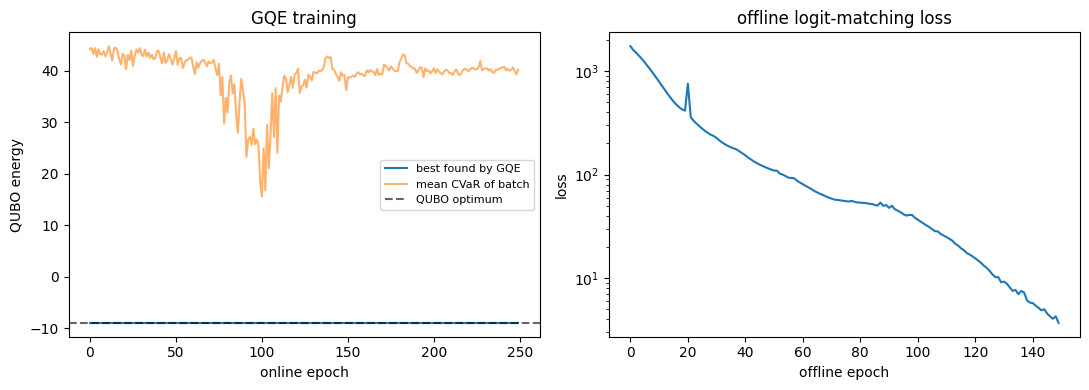

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(hist["best"], label="best found by GQE")
ax[0].plot(hist["mean_cvar"], alpha=0.6, label="mean CVaR of batch")
ax[0].axhline(E.min(), ls="--", c="k", alpha=0.6, label="QUBO optimum")
ax[0].set_xlabel("online epoch"); ax[0].set_ylabel("QUBO energy")
ax[0].set_title("GQE training"); ax[0].legend(fontsize=8)

ax[1].semilogy(hist_off)
ax[1].set_xlabel("offline epoch"); ax[1].set_ylabel("loss")
ax[1].set_title("offline logit-matching loss")
plt.tight_layout(); plt.show()

## What circuit did it learn?

Worth looking at: does the model discover the alternating cost / mixer pattern
of QAOA on its own, or something else?

In [12]:
print("best circuit found:")
for t in best_tokens:
    print("   ", pool["labels"][t])

best circuit found:
    cost(g=0.30)
    mix(b=0.39)
    cost(g=2.40)
    cost(g=0.15)
    mix(b=1.57)
    mix(b=1.18)
    cost(g=4.80)
    mix(b=0.20)


In [13]:
cu.save("gqe_run", {"hist": hist, "hist_off": hist_off,
                    "best_tokens": best_tokens, "best_index": best_index,
                    "db_gqe": db_gqe, "e_gqe": e_gqe, "row": row,
                    "E_min": float(E.min()), "seq_len": SEQ_LEN})
torch.save(model.state_dict(), "results/gqe_model.pt")

saved results/gqe_run.pkl


## What we learned

- The GPT designs circuits that concentrate probability on low-energy structures.
- CVaR, not the plain average, is the right objective for a diagonal Hamiltonian.
- Mixers are essential; cost gates alone do nothing measurable.
- Next: is this actually better than simple classical search? Notebook 04.

In [14]:
# Everything saved so far. These files live in your Drive, so the next
# notebook will find them even after this runtime shuts down.
cu.show_results()

# Uncomment to download a copy to your computer:
# cu.download_results()

file                        size   from notebook
--------------------------------------------------
encoding.pkl                5.2K   02
gqe_model.pt             3113.9K   03
gqe_run.pkl                10.8K   03
refs.pkl                    0.5K   01
